## 1. Data Understanding and Preparation

The dataset is first investigated to understand its structure, data types, missing values, duplicate records, feature types, and target variable.

Data quality issues are identified and addressed before model development. Numerical and categorical features are identified separately, categorical variables are encoded appropriately, and the data is split into training and testing sets using a 70:30 ratio with `random_state=42` to ensure reproducibility.

In [8]:
# Import pandas for data loading and analysis
import pandas as pd

In [9]:
# Load the Telco Customer Churn dataset
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

### Preview the Dataset

The first few records are inspected to understand the structure of the dataset, the types of information available for each customer, and the format of the values in different attributes.

In [10]:
# Load the Telco Customer Churn dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Observation:**

The dataset contains customer-level records with demographic, service, contract, and billing attributes. The target variable `Churn` indicates whether the customer historically churned (`Yes`) or did not churn (`No`).

In [11]:
# Check the number of rows and columns
df.shape


(7043, 21)

The dataset contains 7,043 customer records and 21 attributes, including the target variable Churn.

In [12]:
# Display all column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [13]:
# Check data types and overall structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [16]:
# Check the distribution of the target variable
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
# Calculate the percentage distribution of the target variable, Balanced, Imbalanced
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [18]:
# Investigating: TotalCharges has been shown as string in place of float
df["TotalCharges"].unique()[:20] 

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [19]:
# Check the frequency of TotalCharges values
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [20]:
# Check the data type of TotalCharges
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [21]:
# Check for blank/empty values in TotalCharges
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [22]:
# Display records with blank TotalCharges
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [23]:
# Convert TotalCharges to numeric; invalid/blank values become NaN
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [24]:
# Replace missing TotalCharges values with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [25]:
# Now check the type of TotalCharges, it is converted
df["TotalCharges"].dtype

dtype('float64')

In [26]:
# Check how many value of TotalSum are null
df["TotalCharges"].isnull().sum()

np.int64(0)

### TotalCharges Data Cleaning

The `TotalCharges` attribute represents the total amount charged to a customer but was initially stored as a string. Investigation identified **11 blank values**, all associated with customers having `tenure = 0`.

The blank values were converted to `NaN` using numeric conversion with `errors="coerce"` and then replaced with `0`. This is appropriate for these records because customers with zero tenure have no accumulated charges recorded in the dataset.

The column is now stored as a numeric `float64` type and contains no missing values.

In [27]:
# Remove customerID because it is an identifier and not a predictive feature
# axis=0 → rows, axis=1 → columns
df = df.drop("customerID", axis=1)


In [28]:
# Now check the size of dataframe. 1 column must be removed from 21->20
df.shape

(7043, 20)

In [29]:
# show the columns now, as 1 has been removed, we will no longer see: customerID
# we have removed the customerID before model training too
df.columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

The `customerID` column is removed because it uniquely identifies individual customers but does not provide meaningful information for predicting churn. Removing it also prevents the model from treating customer identifiers as predictive features.

In [30]:
# Identify numerical and categorical features in the dataset

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["str"]
).columns.tolist()

# Remove the target variable from the predictor feature lists
categorical_features.remove("Churn")

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Numerical and Categorical Features

The dataset contains **4 numerical features**: `SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`.

There are **15 categorical features** describing customer demographics, subscribed services, contract details, billing, and payment methods.

The target variable `Churn` is excluded from the predictor features because it represents the outcome that the model will learn to predict.

### Rest of the data preparation in Step 2: EDA 

The assignment requires categorical variable encoding, a **70:30 train/test split**, and `random_state = 42` for reproducibility. These steps will be performed **after Exploratory Data Analysis (EDA) and Feature Engineering**, rather than at this stage.

- **Encoding of categorical variables:** Categorical features will be converted into a numerical representation using **One-Hot Encoding** so that they can be used by the Decision Tree model. This will be performed as part of the final preprocessing pipeline.

- **Train/Test Split:** A **70:30 split** will be performed after all required feature engineering is completed. This ensures that the final model is trained and evaluated using the complete set of selected features, including `ServiceCount` and `IsNewCustomer`.

- **Random Seed:** `random_state = 42` will be used during the train/test split and model training wherever applicable to ensure that the results are reproducible.

To avoid data leakage and unnecessary repetition, the train/test split and preprocessing will be performed **only once** in the Model Preparation section.

## 2. Exploratory Data Analysis (EDA)

### Visualization 1 - Churn Distribution

The first step in EDA is to understand the distribution of the target variable, `Churn`.

This helps determine the proportion of customers who churned versus those who remained with the company and provides an initial understanding of whether the target classes are balanced.

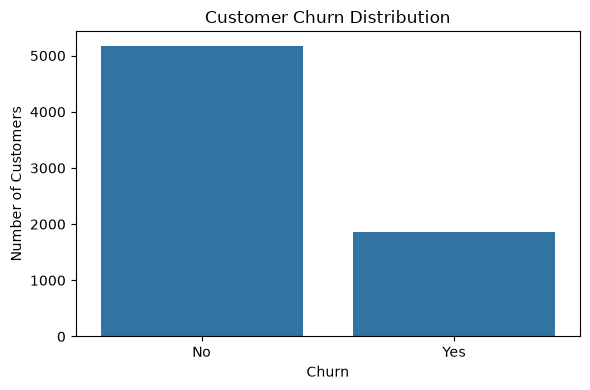

In [31]:
# Visualize the distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4)) # sets the dimensions of the graph to 6 inches wide and 4 inches tall

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [32]:
# Percent distribution
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print(churn_percentage)


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


#### Business Insight

Approximately 73.5% of customers did not churn, while approximately 26.5% of customers churned. This means that roughly one out of every four customers in the dataset has churned.

The churned segment represents a significant customer-retention opportunity, making it important to identify customer characteristics associated with higher churn risk. Also, customers who do not churn form the majority class. Therefore, during model evaluation, metrics such as **Precision, Recall, and F1-score** should also be considered along with Accuracy to assess how effectively the model identifies customers who are likely to churn.

### Visualization 2 - Contract Type vs Churn

Contract type is an important customer characteristic because customers may have different levels of commitment depending on whether they are on a month-to-month, one-year, or two-year contract.

We will compare churn across contract types to determine whether customers with different contract commitments show different churn behavior.

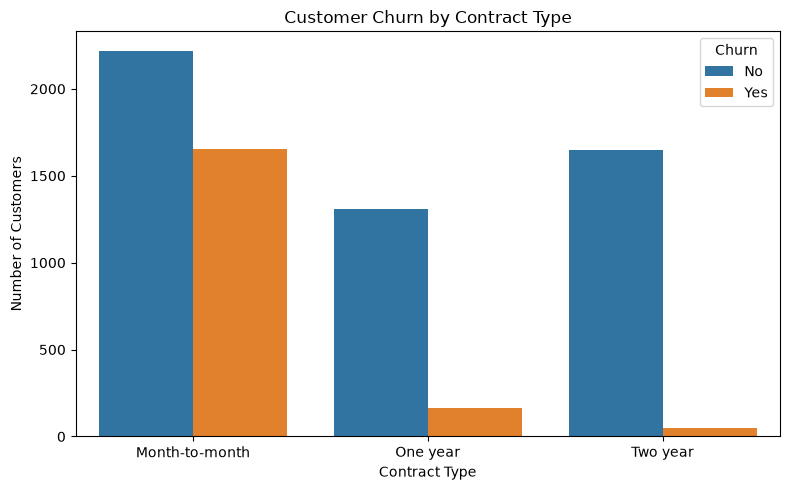

In [33]:
# Compare customer churn counts across different contract types
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [34]:
# but counts alone can sometimes be misleading because the number of customers in each contract group is different.
# So calculate the percentage of customers who churn within each contract type.
# Calculate churn percentage within each contract type
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn_rate)


Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


**Business Observation:**

The churn rate differs substantially across contract types. **Month-to-month customers have the highest churn rate at approximately 42.71%**, compared with **11.27% for one-year contracts** and only **2.83% for two-year contracts**.

This suggests that customers with shorter-term contracts are more likely to churn. From a business perspective, month-to-month customers could be an important target group for retention strategies, such as contract upgrades, loyalty offers, or personalized retention campaigns.

This analysis shows an association between contract type and churn; it does not by itself establish that contract type causes churn.

### Visualization 3 — Internet Service vs Churn

Internet service is an important service-related characteristic that may be associated with customer churn.

We will compare churn across different `InternetService` categories to identify whether customers using different types of internet services exhibit different churn behavior.

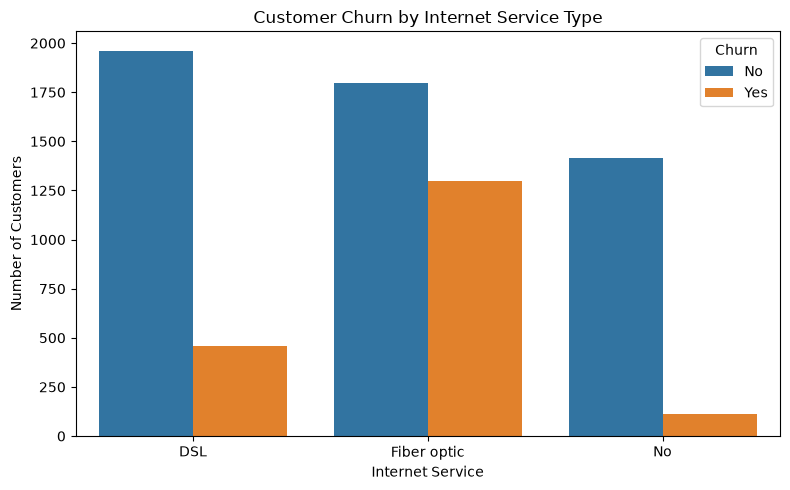

In [35]:
# Compare customer churn counts across internet service types

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [36]:
# Calculate churn percentage within each internet service type
internet_churn_rate = pd.crosstab(   # cross-references two columns to see how they intersect.
    df["InternetService"],          # This forms the rows of your table.
    df["Churn"],                    # his forms the columns of your table
    normalize="index"               # divide the count in each cell by the total number of customers in that specific row.
) * 100
print(internet_churn_rate)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


**Business Observation:**

The churn rate varies considerably across internet service types. Customers using **Fiber optic service have the highest churn rate at approximately 41.89%**, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at approximately 7.40%.

The relatively high churn rate among fiber optic customers indicates that this customer segment may require further investigation. Factors such as pricing, service quality, competition, or customer expectations could potentially contribute to this pattern.

This analysis identifies an association between internet service type and churn; it does not establish a causal relationship.

### Visualization 4 — Tenure Group vs Churn

Customer tenure represents the length of time a customer has been with the company.

To make the relationship easier to interpret, customers will be grouped into tenure ranges and their churn rates will be compared. The `TenureGroup` variable is created only for EDA and will be removed before feature engineering and model preparation.

In [37]:
# Create temporary tenure groups for exploratory analysis
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

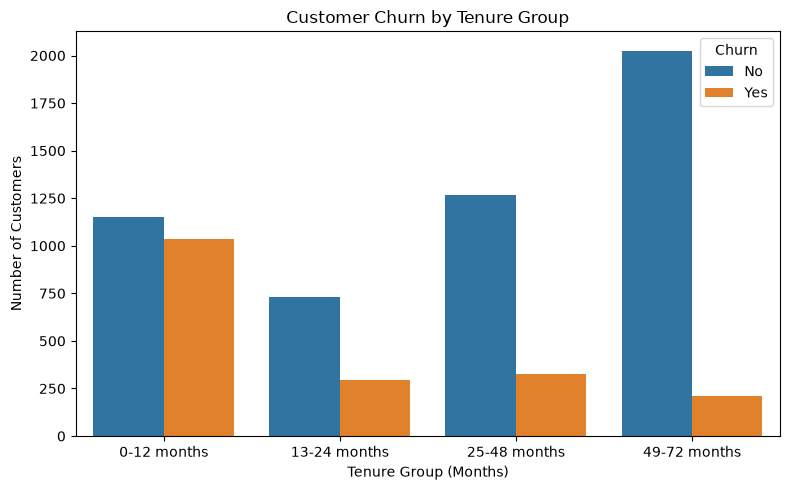

In [38]:
# Compare customer churn counts across tenure groups
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group (Months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [39]:
# Calculate churn percentage within each tenure group
tenure_churn_percentage = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn_percentage

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


**Business Observation:**

The churn rate is highest among customers with shorter tenure. Customers in the **0–12 month group have a churn rate of approximately 47.44%**, while the churn rate decreases to **9.51%** among customers with 49–72 months of tenure.

This indicates that newer customers are substantially more likely to churn than long-term customers. The business could therefore focus retention efforts during the early stages of the customer relationship, when the risk of churn appears to be highest.

This analysis shows an association between customer tenure and churn and does not establish that shorter tenure causes churn.

In [40]:
# Remove the temporary EDA feature before feature engineering
df = df.drop("TenureGroup", axis=1)

### Visualization 5 — Monthly Charges vs Churn

`MonthlyCharges` represents the amount charged to a customer each month.

Comparing monthly charges between customers who churned and those who did not can help identify whether customers with higher or lower monthly charges show different churn patterns.

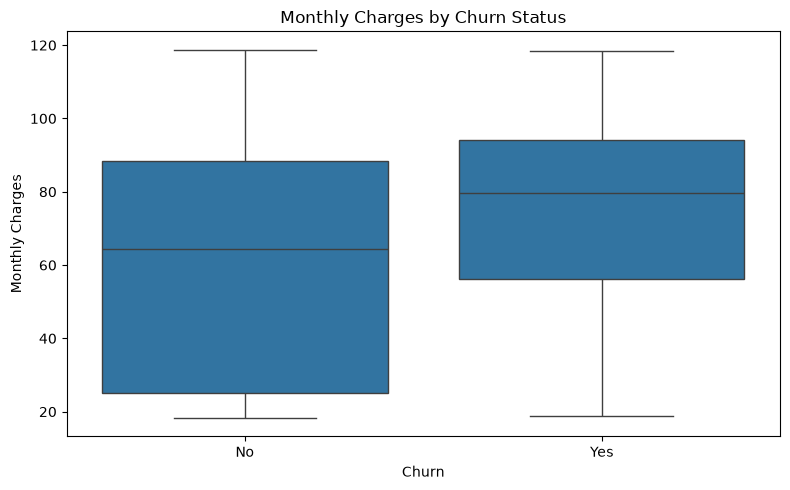

In [41]:
# Compare the distribution of monthly charges for churned and non-churned customers
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

In [42]:
# Calculate mean and median monthly charges for each churn group
monthly_charges_summary = df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median"]
)

monthly_charges_summary

,mean,median
Churn,,
No,61.265124,64.425
Yes,74.441332,79.650


**Business Observation:**

Customers who churned have higher monthly charges on average than customers who did not churn. The average monthly charge for churned customers is approximately **74.44**, compared with **61.27** for non-churned customers. The median follows a similar pattern, at **79.65** for churned customers versus **64.43** for non-churned customers.

This suggests that higher monthly charges are associated with a higher likelihood of churn in this dataset. The business could investigate whether pricing, service bundles, or perceived value may be contributing to churn among customers with higher monthly charges.

The analysis identifies an association and does not establish that higher charges directly cause customers to churn.

### Visualization 6 — Tenure vs Monthly Charges by Churn

The previous visualizations examined individual customer characteristics in relation to churn. This visualization examines the relationship between two numerical variables: `tenure` and `MonthlyCharges`.

A scatter plot is used to determine whether customer tenure and monthly charges show any visible relationship with churn status.

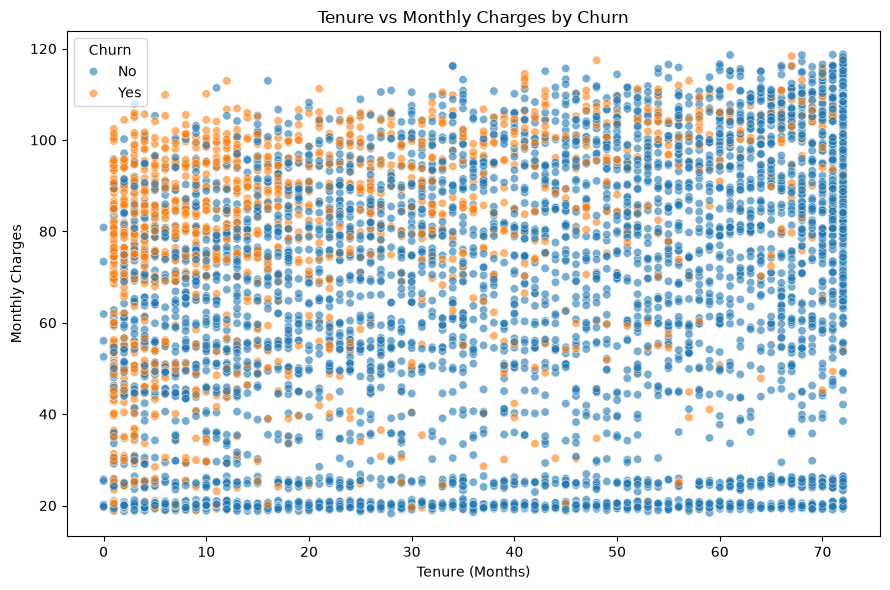

In [43]:
# Visualize the relationship between tenure and monthly charges by churn status
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)

plt.title("Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

**Business Observation:**

The scatter plot shows that churned customers are more concentrated among customers with **lower tenure**, while customers with longer tenure are predominantly associated with the `No` churn category.

Monthly charges vary across both churn groups, but customers with shorter tenure and relatively higher monthly charges appear to contain a noticeable concentration of churned customers.

This suggests that the combination of **customer tenure and monthly charges** may provide useful information for predicting churn. However, the visualization shows an association rather than a causal relationship.

## 3. Feature Engineering

Feature engineering is used to create additional variables that may help the model capture meaningful customer behavior.

Two features are created based on the existing customer-level attributes:

1. **ServiceCount** — the number of additional services subscribed to by the customer.
2. **IsNewCustomer** — identifies customers with a tenure of 12 months or less.

These features are derived only from the available customer attributes and do not use the target variable `Churn`.

### ServiceCount

`ServiceCount` represents the number of additional services subscribed to by a customer.

It is calculated using `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies`.

This feature provides a compact measure of the customer's level of service engagement and may help the model identify differences in churn behavior between customers using fewer or more services.

In [44]:
# Create ServiceCount based on the number of additional services subscribed to
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[service_columns] == "Yes"
).sum(axis=1)

df["ServiceCount"].value_counts().sort_index()

ServiceCount
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [45]:
# Verify the range of ServiceCount
df["ServiceCount"].describe()

count    7043.000000
mean        2.037910
std         1.847682
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: ServiceCount, dtype: float64

### IsNewCustomer

`IsNewCustomer` identifies customers who have been with the company for **12 months or less**.

Customers with `tenure <= 12` are assigned `1`, while customers with tenure greater than 12 months are assigned `0`.

This feature captures early-stage customer status in a simple binary form and may help the model identify customers who are at higher risk of churn during the early part of their relationship with the company.

In [46]:
# Create IsNewCustomer based on customer tenure

df["IsNewCustomer"] = (
    df["tenure"] <= 12
).astype(int)

df["IsNewCustomer"].value_counts().sort_index()

IsNewCustomer
0    4857
1    2186
Name: count, dtype: int64

In [47]:
# Verify the newly created features
df[["tenure", "ServiceCount", "IsNewCustomer"]].head(10)

,tenure,ServiceCount,IsNewCustomer
0,1,1,1
1,34,2,0
2,2,2,1
3,45,3,0
4,2,0,1
5,8,3,1
6,22,2,0
7,10,1,1
8,28,4,0
9,62,2,0


## 4. Model Preparation and Development

The dataset is now ready for machine learning after completing data cleaning, exploratory analysis, and feature engineering.

The target variable `Churn` will be separated from the predictor variables. The data will then be divided into training and testing sets using a **70:30 split** with `random_state=42` to ensure reproducibility.

Categorical variables will be converted into numerical representations using **One-Hot Encoding**. The preprocessing steps will be fitted using only the training data and then applied to both the training and testing data. This prevents information from the test set from influencing the training process and helps avoid data leakage.

In [48]:
# Separate predictor variables and the target variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7043, 21)
Target shape: (7043,)


In [49]:
# Train/Test Split, splitted in X and y
# We are doing this as the model must not learn from the test data during training.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4930, 21)
X_test: (2113, 21)
y_train: (4930,)
y_test: (2113,)


In [50]:
# As we have added two more cells it will change number of numberical and categorical features
# Numerical features
numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "IsNewCustomer"
]

# Categorical features
categorical_features = X.select_dtypes(include="str").columns.tolist()

print("Numerical features:", numerical_features)
print("\nNumber of numerical features:", len(numerical_features))

print("\nCategorical features:", categorical_features)
print("\nNumber of categorical features:", len(categorical_features))

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'IsNewCustomer']

Number of numerical features: 6

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of categorical features: 15


### Encoding Categorical Variables

The Decision Tree model requires the input features to be represented numerically. The dataset contains 15 categorical features, so **One-Hot Encoding** will be used to convert each category into a separate binary feature.

The numerical features will be passed through without transformation.

`handle_unknown="ignore"` is used so that the preprocessing pipeline can handle a category that was not present in the training data when making predictions on new or unseen customer data.

The preprocessor will be fitted **only on the training data** and then applied to both the training and testing data to prevent data leakage.

In [51]:
# Create a preprocessing transformer for numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [52]:
# Fit the preprocessor only on the training data
# Then apply the same transformation to training and test data
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)


Processed X_train shape: (4930, 47)
Processed X_test shape: (2113, 47)


### Preprocessing Verification

The preprocessing step transformed the **21 original predictor features into 47 model-ready features**. The increase is due to One-Hot Encoding of the categorical variables, while the six numerical features were passed through without transformation.

The preprocessor was fitted only on the training data and the same transformation was applied to the test data. This ensures that both datasets have a consistent feature representation while preventing information from the test set from influencing preprocessing.

In [53]:
# Get the feature names after preprocessing and one-hot encoding

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 47

Processed feature names:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__ServiceCount' 'num__IsNewCustomer'
 'cat__gender_Female' 'cat__gender_Male' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__PhoneService_No' 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMov

### Processed Feature Names

After preprocessing, the dataset contains **47 model-ready features**. The numerical features retain their original representation, while categorical variables are expanded into separate binary features through One-Hot Encoding.

The generated feature names are retained for later **feature importance analysis and Decision Tree interpretation**.

## Model Development — Decision Tree Classifier

A **Decision Tree Classifier** as a Decision Tree model for customer churn prediction.

Two configurations will be developed:

- **Model 1:** A default Decision Tree without explicit depth restrictions. This provides a baseline model.
- **Model 2:** A constrained Decision Tree using `max_depth=5` and `min_samples_split=10` to reduce model complexity and improve generalization.

Both models will be trained using the same training data and evaluated on the same unseen test data so that their performance can be compared fairly.

### Model 1 — Baseline Decision Tree

The first model is a baseline Decision Tree Classifier using the default model configuration with a fixed random state for reproducibility.

This baseline provides a reference point against which the second Decision Tree configuration can be compared.

In [54]:
# Train the baseline Decision Tree model
# Our first model is our baseline with essentially unrestricted tree growth.
from sklearn.tree import DecisionTreeClassifier

dt_model_1 = DecisionTreeClassifier(
    random_state=42
)

dt_model_1.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
y_pred_1 = dt_model_1.predict(X_test_processed)

# Generate churn probabilities
y_prob_1 = dt_model_1.predict_proba(X_test_processed)[:, 1]

### Model 2 — Controlled Decision Tree

The second Decision Tree configuration applies restrictions to the tree complexity.

`max_depth=5` limits the maximum depth of the tree, while `min_samples_split=10` requires at least 10 samples in a node before it can be split.

These parameters are intended to reduce unnecessary tree complexity and help control overfitting.

The performance of this model will be compared with the baseline Decision Tree using the test-set evaluation metrics.

In [55]:

# Our second model has:
# max_depth=5 → tree can have at most 5 levels
# min_samples_split=10 → a node needs at least 10 samples before it can be split
# random_state=42 → reproducible results
# trying to reduce overfitting
# Train a constrained Decision Tree to reduce model complexity

dt_model_2 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt_model_2.fit(
    X_train_processed,
    y_train
)

# Generate predictions on the test data
y_pred_2 = dt_model_2.predict(X_test_processed)

# Generate churn probabilities
y_prob_2 = dt_model_2.predict_proba(X_test_processed)[:, 1]

## 5. Model Evaluation and Comparison

Both Decision Tree configurations will be evaluated on the same unseen test dataset.

The following metrics are used as required by the assignment:

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Proportion of customers predicted as churners who actually churned.
- **Recall:** Proportion of actual churners correctly identified by the model.
- **F1-score:** Harmonic mean of Precision and Recall, providing a balance between the two.
- **Confusion Matrix:** Shows the numbers of true negatives, false positives, false negatives, and true positives.

Since the business objective is to identify customers who are likely to churn for proactive retention, **Recall is particularly important** because a false negative represents a customer who churns but was not identified by the model. However, Precision and F1-score will also be considered because retention actions may involve business costs.

In [56]:
# Evaluate both Decision Tree models using the required classification metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Model 1 metrics
accuracy_1 = accuracy_score(y_test, y_pred_1)
precision_1 = precision_score(y_test, y_pred_1, pos_label="Yes")
recall_1 = recall_score(y_test, y_pred_1, pos_label="Yes")
f1_1 = f1_score(y_test, y_pred_1, pos_label="Yes")
cm_1 = confusion_matrix(y_test, y_pred_1, labels=["No", "Yes"])

# Model 2 metrics
accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score(y_test, y_pred_2, pos_label="Yes")
recall_2 = recall_score(y_test, y_pred_2, pos_label="Yes")
f1_2 = f1_score(y_test, y_pred_2, pos_label="Yes")
cm_2 = confusion_matrix(y_test, y_pred_2, labels=["No", "Yes"])

print("Model 1 — Baseline Decision Tree")
print(f"Accuracy : {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall   : {recall_1:.4f}")
print(f"F1-score : {f1_1:.4f}")
print("Confusion Matrix:")
print(cm_1)

print("\nModel 2 — Constrained Decision Tree")
print(f"Accuracy : {accuracy_2:.4f}")
print(f"Precision: {precision_2:.4f}")
print(f"Recall   : {recall_2:.4f}")
print(f"F1-score : {f1_2:.4f}")
print("Confusion Matrix:")
print(cm_2)

Model 1 — Baseline Decision Tree
Accuracy : 0.7373
Precision: 0.5175
Recall   : 0.4895
F1-score : 0.5031
Confusion Matrix:
[[1277  262]
 [ 293  281]]

Model 2 — Constrained Decision Tree
Accuracy : 0.7937
Precision: 0.6206
Recall   : 0.6185
F1-score : 0.6195
Confusion Matrix:
[[1322  217]
 [ 219  355]]


### Model Comparison and Selection

The two Decision Tree configurations are compared using the evaluation metrics obtained on the same test dataset.

| Metric | Model 1 — Baseline | Model 2 — Constrained |
|---|---:|---:|
| Accuracy | 73.73% | **79.37%** |
| Precision | 51.75% | **62.06%** |
| Recall | 48.95% | **61.85%** |
| F1-score | 50.31% | **61.95%** |

Model 2 performs better than the baseline model across all four evaluation metrics. In particular, its Recall improves from **48.95% to 61.85%**, meaning that it identifies a substantially larger proportion of the customers who actually churn.

Model 2 is therefore selected as the preferred Decision Tree configuration. Its improved performance, together with its constrained tree complexity, indicates better generalization to unseen customers.

**Business Interpretation:**

For the telecom company, identifying potential churners is important because these customers can be targeted with proactive retention actions.

Model 2 correctly identifies **61.85% of the actual churners**, compared with 48.95% for Model 1. This reduces the number of potential churners that the business fails to identify.

Although Precision is also important because retention campaigns have a cost, the improvement in Recall makes Model 2 more suitable for the business objective of identifying customers at risk of churn.

### Overfitting and Generalization Analysis

A comparison between training and test performance is used to assess whether the Decision Tree models generalize well to unseen data.

A large difference between training and test accuracy can indicate **overfitting**, where the model learns the training data too closely but performs poorly on new data.

The constrained Model 2 is expected to generalize better because its tree complexity is limited using `max_depth=5` and `min_samples_split=10`.

In [57]:
# Compare training and test accuracy to assess model generalization

train_accuracy_1 = accuracy_score(
    y_train,
    dt_model_1.predict(X_train_processed)
)

train_accuracy_2 = accuracy_score(
    y_train,
    dt_model_2.predict(X_train_processed)
)

print("Model 1 — Baseline Decision Tree")
print(f"Training Accuracy: {train_accuracy_1:.4f}")
print(f"Test Accuracy    : {accuracy_1:.4f}")
print(f"Accuracy Gap     : {train_accuracy_1 - accuracy_1:.4f}")

print("\nModel 2 — Constrained Decision Tree")
print(f"Training Accuracy: {train_accuracy_2:.4f}")
print(f"Test Accuracy    : {accuracy_2:.4f}")
print(f"Accuracy Gap     : {train_accuracy_2 - accuracy_2:.4f}")

Model 1 — Baseline Decision Tree
Training Accuracy: 0.9984
Test Accuracy    : 0.7373
Accuracy Gap     : 0.2610

Model 2 — Constrained Decision Tree
Training Accuracy: 0.8028
Test Accuracy    : 0.7937
Accuracy Gap     : 0.0092


**Overfitting Observation:**

Model 1 achieves approximately **99.84% training accuracy** but only **73.73% test accuracy**, resulting in an accuracy gap of approximately **26.10 percentage points**. This large gap indicates significant overfitting.

Model 2 achieves approximately **80.28% training accuracy** and **79.37% test accuracy**, with a much smaller gap of approximately **0.92 percentage points**.

Therefore, Model 2 demonstrates substantially better generalization to unseen data. This supports the selection of Model 2 as the final Decision Tree model.

## 6. Model Interpretation

Model interpretation helps identify which customer attributes contribute most to the Decision Tree's predictions.

The selected **Model 2** will be interpreted using feature importance and a visualization of the Decision Tree. These results can help the business understand the characteristics most strongly associated with the model's churn predictions.

### Feature Importance

Decision Tree feature importance measures the contribution of each processed feature to reducing impurity across the tree.

Because categorical variables were One-Hot Encoded, the importance values are reported for the individual encoded categories rather than only the original categorical columns.

The most important features will be examined to identify the customer characteristics that contribute most to the model's churn predictions.

In [66]:
# table of the top 15 most important model features.
import pandas as pd

# get all the feature names
feature_names = preprocessor.get_feature_names_out()

# total weighted impurity reduction contributed by each feature across the tree. Gini for impurity reduction 
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model_2.feature_importances_
})

# sorting it
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# First 15 features
feature_importance.head(10)

,Feature,Importance
38,cat__Contract_Month-to-month,0.506988
20,cat__OnlineSecurity_No,0.140281
1,num__tenure,0.110225
17,cat__InternetService_DSL,0.078176
3,num__TotalCharges,0.062856
2,num__MonthlyCharges,0.048035
40,cat__Contract_Two year,0.018909
45,cat__PaymentMethod_Electronic check,0.017574
0,num__SeniorCitizen,0.009269
37,cat__StreamingMovies_Yes,0.007574


### Top 10 Feature Importances

The feature importance values are visualized to make the most influential features easier to compare.

Only the top 10 processed features are shown in the chart for readability. The complete feature importance table remains available in the previous output.

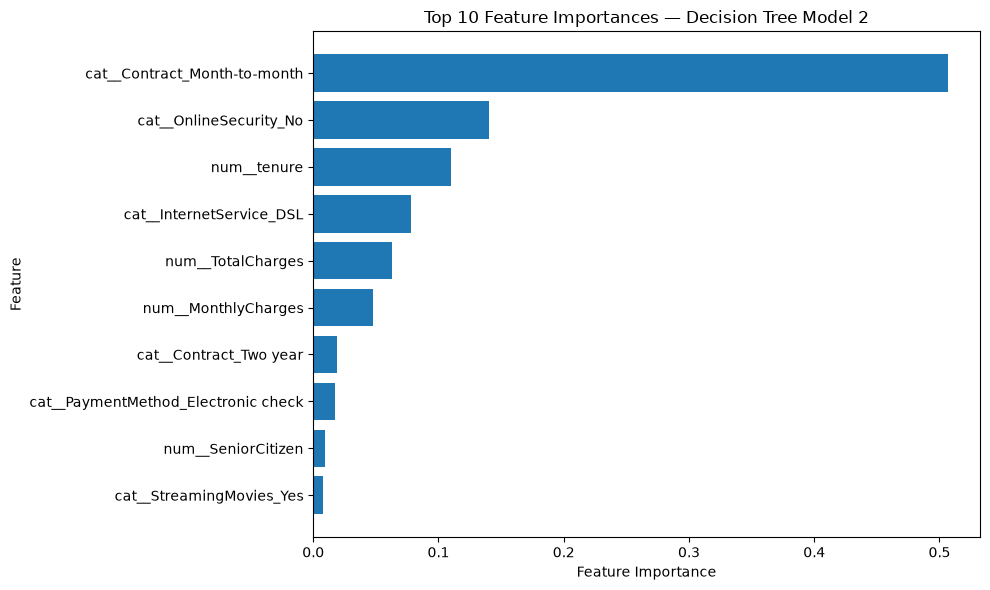

In [63]:
# Visualize the top 10 most important features

top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances — Decision Tree Model 2")
plt.tight_layout()
plt.show()

**Feature Importance Observation:**

The most influential feature is **`Contract_Month-to-month`**, followed by **`OnlineSecurity_No`** and **`tenure`**.

The high importance of `Contract_Month-to-month` is consistent with the earlier EDA, where month-to-month customers showed a substantially higher churn rate than customers on one-year or two-year contracts.

`tenure` is also among the most important numerical features, supporting the EDA finding that customers with shorter tenure have higher churn rates.

The feature importance results represent how the Decision Tree uses features to reduce impurity during splitting. They indicate which features are most useful to the trained model and should not be interpreted as proof that these features independently cause churn.

### Decision Tree Visualization and Interpretation

Visualizing the Decision Tree provides a direct view of how the selected model makes classification decisions.

The complete tree can contain many nodes, so the first three levels are displayed for readability. The visualization shows the feature used for each split, the impurity of the resulting node, the number of samples reaching the node, and the predicted class.

The tree will be interpreted together with the feature importance results to identify the major decision patterns used by the model.

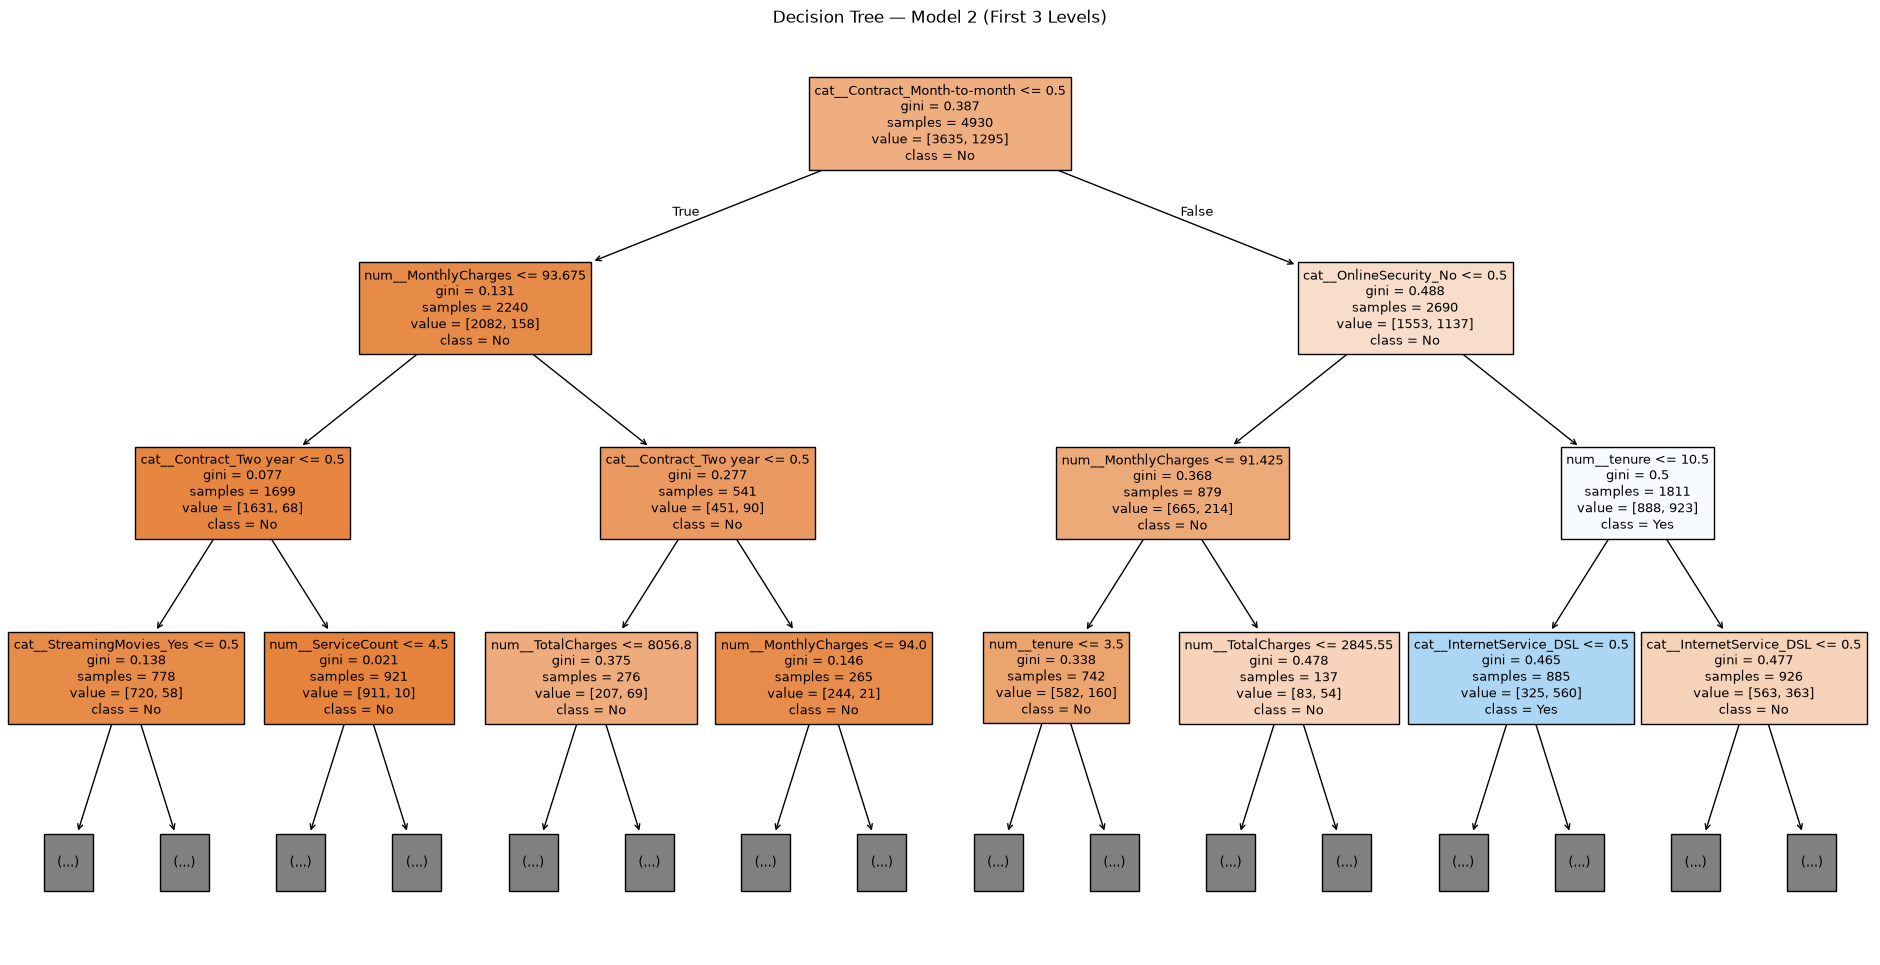

In [64]:
# Visualize the first three levels of the selected Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    dt_model_2,
    feature_names=feature_names,
    class_names=dt_model_2.classes_,
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree — Model 2 (First 3 Levels)")
plt.show()

**Decision Tree Interpretation:**

The root node of the selected Decision Tree uses **`Contract_Month-to-month`** as the first splitting feature. This is consistent with its high feature importance and the earlier EDA finding that month-to-month customers have a substantially higher churn rate.

Customers are then divided into smaller groups using features such as **`MonthlyCharges`**, **`OnlineSecurity_No`**, **`tenure`**, and **`InternetService_DSL`**.

The `Gini` value shown at each node represents the impurity of that node. A lower Gini value indicates that the customers at that node are more homogeneous with respect to the churn classes.

For example, branches containing a higher proportion of churned customers are more likely to result in a `Yes` prediction. The tree therefore provides an interpretable sequence of customer characteristics that the model uses to distinguish between churn and non-churn customers.

## Bonus 1: Handling Class Imbalance

The target variable is imbalanced, with 73.46% of customers having `Churn = No` and 26.54% having `Churn = Yes`.

Since churned customers are the minority class, a balanced Decision Tree is tested using `class_weight="balanced"`. It computes weights inversely proportional to class frequencies.

The balanced model is evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix and compared with the original Decision Tree model.

In [67]:
balanced_dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

balanced_dt_model.fit(X_train_processed, y_train)

y_pred_balanced = balanced_dt_model.predict(X_test_processed)

In [68]:
balanced_accuracy = accuracy_score(
    y_test, y_pred_balanced
)

balanced_precision = precision_score(
    y_test, y_pred_balanced, pos_label="Yes"
)

balanced_recall = recall_score(
    y_test, y_pred_balanced, pos_label="Yes"
)

balanced_f1 = f1_score(
    y_test, y_pred_balanced, pos_label="Yes"
)

balanced_cm = confusion_matrix(
    y_test,
    y_pred_balanced,
    labels=["No", "Yes"]
)

print(f"Accuracy : {balanced_accuracy:.4f}")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall   : {balanced_recall:.4f}")
print(f"F1 Score : {balanced_f1:.4f}")

print("\nConfusion Matrix:")
print(balanced_cm)

Accuracy : 0.7459
Precision: 0.5205
Recall   : 0.8171
F1 Score : 0.6359

Confusion Matrix:
[[1107  432]
 [ 105  469]]


### Analysis

Compared with the original Decision Tree (Model 2), applying
`class_weight="balanced"` changes the model's focus toward the minority
`Churn = Yes` class.

The balanced model identifies substantially more actual churners:

- Recall increased from **61.85% to 81.71%**.
- False negatives decreased from **219 to 105**.

However, this improvement comes with more false positives:

- False positives increased from **217 to 432**.
- Precision decreased from **62.06% to 52.05%**.
- Accuracy decreased from **79.37% to 74.59%**.

The F1 score increased slightly from **61.95% to 63.59%**, showing that
the improvement in recall partly compensates for the reduction in precision.

### Outcome

Class balancing successfully improved the model's ability to identify
customers who actually churn. This is useful when missing a potential
churner is considered more costly than contacting some customers who
would not have churned.

However, the balanced model also generates more false-positive retention
cases. Therefore, class balancing introduces a clear trade-off between
**recall and precision**.

For this assignment, the balanced Decision Tree is retained as a bonus
experiment rather than replacing the existing final deployed model.

## Bonus 2: Random Forest Classifier

A Random Forest is an ensemble learning method that combines multiple
Decision Trees to make predictions.

As an additional model, a Random Forest Classifier is trained using the
same training data and preprocessed features used for the Decision Tree
models.

The model is evaluated using Accuracy, Precision, Recall, F1-score, and
Confusion Matrix.

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)

In [70]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["No", "Yes"]
)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

print("\nConfusion Matrix:")
print(rf_cm)

Accuracy : 0.7875
Precision: 0.6521
Recall   : 0.4669
F1 Score : 0.5442

Confusion Matrix:
[[1396  143]
 [ 306  268]]


### Analysis

Compared with the controlled Decision Tree (Model 2), the Random Forest
achieves similar accuracy but shows a different precision-recall trade-off.

The Random Forest achieves **78.75% accuracy** and **65.21% precision**,
which is slightly higher than Model 2.

However, its recall decreases from **61.85% to 46.69%**, meaning that the
Random Forest identifies fewer of the customers who actually churn.

The confusion matrix also shows:

- False positives: **143**
- False negatives: **306**

Therefore, the Random Forest makes fewer false-positive predictions but
misses more actual churners.

Its F1 score of **54.42%** is lower than Model 2's **61.95%**, indicating
that the balance between precision and recall is lower for this experiment.

### Outcome

The Random Forest demonstrates that an additional ensemble model can
produce a different precision-recall trade-off from the Decision Tree.

For this dataset and configuration, the Random Forest provides higher
precision but lower recall and F1 score than the controlled Decision Tree.

The Random Forest is therefore documented as an additional model
experiment and is not used to replace the existing deployed pipeline.

## 7. Model saving and pipeline distribution

The selected Decision Tree model needs to be packaged together with the feature engineering and preprocessing steps so that the same transformations are applied consistently during prediction.

The final pipeline will perform the following steps:

1. Create the engineered features `ServiceCount` and `IsNewCustomer`.
2. Apply the numerical and categorical preprocessing.
3. Use the selected Decision Tree classifier to generate the prediction.

This ensures that new customer data received by the REST API can be provided in its original format without requiring manual feature engineering or encoding.

In [71]:
# Add the project root directory to Python's module search path

import sys
from pathlib import Path

project_root = Path.cwd().parent   # cwd: current working directory
sys.path.append(str(project_root))

# Import the feature engineering function used by the final pipeline
from feature_engineering import prepare_features

### Build and Train the Final Pipeline

The final pipeline combines the feature engineering, preprocessing, and the selected Decision Tree configuration into a single deployable object.

The Decision Tree configuration is the same as the selected Model 2 (`max_depth=5` and `min_samples_split=10`). The pipeline is fitted once using the existing training dataset.

This does not represent a third model configuration. It packages the final selected modeling approach into a single pipeline so that the same feature engineering and preprocessing steps are automatically applied when making predictions on new customer data.

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Build pipeline
final_pipeline = Pipeline(
    steps=[
# Runs your custom prepare_features Python function on the raw Pandas DataFrame.
        ("feature_engineering",
         FunctionTransformer(
             prepare_features,
             validate=False
         )),

# Typically a ColumnTransformer that handles standard data prep for numerical and categorical features.
        ("preprocessor", preprocessor),

# decision tree classifier as per the same configuration used for model 2
         (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=10,
                random_state=42
            )
        )
    ]
)

In [73]:
# Train the final pipeline using the existing training dataset
final_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','ServiceCount', 'IsNewCustomer']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function pre...001AEDF1E9380>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


### Final Pipeline Verification

The final pipeline is evaluated on the same test dataset used for Model 2.

The test accuracy should match the previously evaluated Model 2 because the pipeline uses the same feature engineering, preprocessing, Decision Tree configuration, training data, and random seed.

In [74]:
# Verify that the final pipeline produces the expected test performance

pipeline_predictions = final_pipeline.predict(X_test)

pipeline_accuracy = accuracy_score(
    y_test,
    pipeline_predictions
)

print(f"Final Pipeline Test Accuracy: {pipeline_accuracy:.4f}")

Final Pipeline Test Accuracy: 0.7937


### Model Persistence

The final trained pipeline will be saved so that it can be reused for predictions without retraining the model.

The saved pipeline contains the complete prediction workflow:

**Feature Engineering → Preprocessing → Decision Tree Classifier**

This allows the REST API to load a single model file and apply the same transformations used during training to new customer data.

In [75]:
# joblib.dump() saves your entire trained scikit-learn pipeline into a file on your disk so you can reuse or deploy it later without retraining
# a Python tool optimized for serializing (saving) large Python objects, particularly NumPy arrays and complex scikit-learn estimators
import joblib
from pathlib import Path

# created the path as required
model_path = Path("../model/churn_model.pkl")

# Serializes the final_pipeline object into a binary .pkl (pickle) file.
# Pickling is the process of converting an in-memory Python object (like a dictionary, list, custom class, or machine learning model) into a byte stream 
# so it can be saved to a file or sent over a network. "Unpickling" is the inverse operation, converting that byte stream back into a fully functional Python object
joblib.dump(
    final_pipeline,
    model_path
)

print(f"Model saved successfully to: {model_path}")

Model saved successfully to: ..\model\churn_model.pkl


In [76]:
# Verify that the saved model file exists

print("File exists:", model_path.exists())

if model_path.exists():
    print("File size:", model_path.stat().st_size, "bytes")

File exists: True
File size: 12811 bytes


**Model Persistence Observation:**

The final trained pipeline has been successfully saved as `churn_model.pkl` in the `model` directory.

The saved artifact contains the feature engineering, preprocessing, and Decision Tree model required to make predictions on new customer data.

## New Customer Prediction

The final pipeline will be tested using a new customer record that was not part of the original training or test dataset.

The customer information is provided in its original form. The pipeline will automatically:

1. Create the engineered features `ServiceCount` and `IsNewCustomer`.
2. Apply the same preprocessing and One-Hot Encoding used during training.
3. Generate a churn prediction.
4. Return the model-estimated probability associated with the predicted churn class.

This demonstrates how the trained model can be used for a real-world customer prediction scenario.

In [77]:
# Create a sample new customer for prediction
new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 425.0
}])

new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,No,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,85.0,425.0


In [78]:
# prediction for the new customer
new_prediction = final_pipeline.predict(new_customer)[0]

# probability for new customer
new_probabilities = final_pipeline.predict_proba(new_customer)[0]

# classes from the decision tree
classes = final_pipeline.named_steps["classifier"].classes_

# prediction probabilities
prediction_probability = new_probabilities[
    list(classes).index(new_prediction)
]

print("Churn Prediction:", new_prediction)
print("Churn Probability:", round(float(prediction_probability), 4))

Churn Prediction: Yes
Churn Probability: 0.6782


**Prediction Observation:**

The sample customer is predicted as **`Yes` for churn**, with a model-estimated probability of approximately **67.82%** for the predicted class.

The customer has characteristics such as short tenure, a month-to-month contract, fiber optic internet service, and relatively high monthly charges, which are consistent with several patterns identified during EDA and feature importance analysis.

The probability is a model output and should be interpreted as an estimate from the trained Decision Tree rather than a guaranteed outcome.

## REST API

A REST API is created using **Flask** to expose the trained customer churn model for prediction.

The API provides a `POST /predict` endpoint that accepts customer information in JSON format.

The saved `churn_model.pkl` pipeline is loaded by the API. Since the saved artifact contains feature engineering, preprocessing, and the Decision Tree classifier, the API can accept raw customer attributes without requiring the caller to manually create `ServiceCount`, `IsNewCustomer`, or perform One-Hot Encoding.

The API returns:

- The predicted churn class (`Yes` or `No`)
- The model-estimated probability associated with the predicted class

Invalid or incomplete input is handled with an appropriate error response.

### Sample API Request
The API accepts a JSON object containing the customer's raw attributes.
The sample request mentioned in sample_request.json represents the same customer used for testing the final pipeline.

In [79]:
# Sample Request
{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 425.0
}

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'No',
 'Dependents': 'No',
 'tenure': 5,
 'PhoneService': 'Yes',
 'MultipleLines': 'No',
 'InternetService': 'Fiber optic',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'No',
 'DeviceProtection': 'No',
 'TechSupport': 'No',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'Yes',
 'Contract': 'Month-to-month',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Electronic check',
 'MonthlyCharges': 85.0,
 'TotalCharges': 425.0}

In [80]:
# Sample Response
{
  "churn_prediction": "Yes",
  "churn_probability": 0.6782
}

{'churn_prediction': 'Yes', 'churn_probability': 0.6782}

### API Testing Results

The REST API was tested using a sample customer request.

**Valid request result:**
- Churn Prediction: **Yes**
- Churn Probability: **0.6782**

The API was also tested with an incomplete request. The API correctly returned a **400 Bad Request** response and identified the missing required fields.

This confirms that the API supports prediction for valid customer input and performs basic input validation for incomplete requests.